In [1]:
print('all ok')

all ok


In [2]:
#load environment variables
import os
from dotenv import load_dotenv
load_dotenv()

True

In [5]:
from langchain_groq import ChatGroq
llm = ChatGroq(
    model_name="deepseek-r1-distill-llama-70b",
    temperature=0
)
response = llm.invoke("What is the capital of France?")
print(response.content)

<think>

</think>

The capital of France is Paris.


In [6]:
# A ReAct agent is an AI agent that combines reasoning and acting in an interactive loop.
# "ReAct" stands for "Reasoning and Acting". In the context of language models and AI agents,
# it refers to a framework where the agent reasons about the task, takes actions (such as calling tools or APIs),
# observes the results, and continues reasoning based on new information.
# This approach enables the agent to solve complex problems by iteratively thinking and interacting with its environment.

In [7]:
from langchain.agents import Tool, initialize_agent
from langchain.agents import AgentType

# Define example tools
def add_numbers(a: int, b: int) -> int:
    return a + b

def multiply_numbers(a: int, b: int) -> int:
    return a * b

tools = [
    Tool(
        name="Addition Tool",
        func=lambda x: add_numbers(*map(int, x.split())),
        description="Adds two numbers. Input format: 'a b'"
    ),
    Tool(
        name="Multiplication Tool",
        func=lambda x: multiply_numbers(*map(int, x.split())),
        description="Multiplies two numbers. Input format: 'a b'"
    ),
]

# Initialize a ReAct agent with multiple tools
agent = initialize_agent(
    tools,
    llm,
    agent=AgentType.ZERO_SHOT_REACT_DESCRIPTION,
    verbose=True
)

# ASCII diagram for ReAct agent with multiple tools
multi_tool_asci = """
ReAct Agent with Multiple Tools (ASCII Art):

+-------------------+
|   User Question   |
+-------------------+
          |
          v
+-------------------+
|   Reasoning Step  |
+-------------------+
          |
          v
+-------------------+      +----------------------+
|   Tool Selection  |----->|   Tool 1: Addition   |
+-------------------+      +----------------------+
          |                        ^
          |                        |
          |                +----------------------+
          |--------------->| Tool 2: Multiplication|
                           +----------------------+
          |
          v
+-------------------+
|  Observation Step |
+-------------------+
          |
          v
+-------------------+
|   Final Answer    |
+-------------------+
"""

print(multi_tool_asci)


ReAct Agent with Multiple Tools (ASCII Art):

+-------------------+
|   User Question   |
+-------------------+
          |
          v
+-------------------+
|   Reasoning Step  |
+-------------------+
          |
          v
+-------------------+      +----------------------+
|   Tool Selection  |----->|   Tool 1: Addition   |
+-------------------+      +----------------------+
          |                        ^
          |                        |
          |                +----------------------+
          |--------------->| Tool 2: Multiplication|
                           +----------------------+
          |
          v
+-------------------+
|  Observation Step |
+-------------------+
          |
          v
+-------------------+
|   Final Answer    |
+-------------------+



/var/folders/r6/b87zwk157sz4fy3q2qlsmrp00000gn/T/ipykernel_20240/4193369648.py:25: LangChainDeprecationWarning: LangChain agents will continue to be supported, but it is recommended for new use cases to be built with LangGraph. LangGraph offers a more flexible and full-featured framework for building agents, including support for tool-calling, persistence of state, and human-in-the-loop workflows. For details, refer to the `LangGraph documentation <https://langchain-ai.github.io/langgraph/>`_ as well as guides for `Migrating from AgentExecutor <https://python.langchain.com/docs/how_to/migrate_agent/>`_ and LangGraph's `Pre-built ReAct agent <https://langchain-ai.github.io/langgraph/how-tos/create-react-agent/>`_.
  agent = initialize_agent(


In [8]:
from langchain.tools import tool

## Custom Tools

In [9]:
@tool
def multiply(a: int, b: int) -> int:
    """Multiplies two numbers."""
    return a * b
@tool
def add(a: int, b: int) -> int:
    """Adds two numbers."""
    return a + b
@tool
def divide(a: int, b: int) -> float:
    """Divides two numbers."""
    if b == 0:
        raise ValueError("Cannot divide by zero.")
    return a / b


## Importing inbuild tools

In [10]:
import time
from langchain_community.tools import DuckDuckGoSearchRun

# Add a delay before searching
time.sleep(2)

try:
    search = DuckDuckGoSearchRun()
    result = search.invoke('what is the latest update in iphone 17?')
    print(result)
except Exception as e:
    print(f"Search failed: {e}")
    print("Try again in a few seconds...")

Apple has released the latest versions of its iPhone and iPad software: iOS 17.6 and iPadOS 17.6 are now available for download on your device. Here's what's new in these latest OS updates. Apple just released a surprise iPhone update: iOS 17.6.1. You can tell from the numbering that this is a minor update and you'd be right if you guessed there were no new features. Here's what ... iOS 16.4 introduced a code that makes iPhone updates download by default, with Apple evidently hoping that the change will ensure that most people are running the latest version of iOS. The iPhone is already near the top of our best phone list, and this extra layer of security offered by iOS 17.6 is just icing on the cake. And if you're unsure how to update your iPhone , read our ... iOS 17 is the newest version of iOS, the operating system that is designed to run on the iPhone.Previewed in June, iOS 17 is available now on the iPhone XR/XS and later. There are new features for ...


In [ ]:
# Alternative 1: Use Tavily Search (requires API key)
# !pip install tavily-python
# from langchain_community.tools.tavily_search import TavilySearchResults

# Alternative 2: Use Wikipedia search
from langchain_community.tools import WikipediaQueryRun
from langchain_community.utilities import WikipediaAPIWrapper

wikipedia = WikipediaQueryRun(api_wrapper=WikipediaAPIWrapper())
result = wikipedia.invoke("iPhone 17 rumors specifications")
print(result)

Page: IOS 17
Summary: iOS 17 is the seventeenth major release of Apple's iOS operating system for the iPhone. It is the direct successor to iOS 16. It was announced on June 5, 2023, at Apple's annual Worldwide Developers Conference alongside watchOS 10, iPadOS 17, tvOS 17 and macOS Sonoma. It was made publicly available on September 18, 2023, as a free software update for supported iOS devices (see the supported devices section). It was succeeded by iOS 18 on September 16, 2024.

Page: IPhone 14
Summary: The iPhone 14 and iPhone 14 Plus are smartphones developed and marketed by Apple Inc. They are the sixteenth-generation iPhones, succeeding the iPhone 13 and iPhone 13 Mini, and were announced during Apple Event, Apple Park in Cupertino, California, on September 7, 2022, alongside the higher-priced iPhone 14 Pro and iPhone 14 Pro Max flagships. The iPhone 14 and iPhone 14 Plus feature a 6.1-inch (15 cm) and 6.7-inch (17 cm) display, improvements to the rear-facing camera, and satellite

In [11]:
from langchain_community.utilities import DuckDuckGoSearchAPIWrapper
from langchain_community.tools import DuckDuckGoSearchRun

# Configure with different settings
wrapper = DuckDuckGoSearchAPIWrapper(
    region="us-en",
    time="y",  # past year
    max_results=3,
    safesearch="moderate"
)

search = DuckDuckGoSearchRun(api_wrapper=wrapper)

# Add delay and try
import time
time.sleep(3)

try:
    result = search.invoke('iPhone 17 latest news')
    print(result)
except Exception as e:
    print(f"Search still failed: {e}")

Macworld reports on the latest iPhone 17 rumors, including a new slim model called iPhone Air, a possible folding iPhone, and a new color option. Find out what to expect from the 2025 iPhone lineup and how it compares to the iPhone 16. Learn about the latest rumors and features for the iPhone 17 models planned for 2025, including a new ultra-thin design, ProMotion displays, Wi-Fi 7, and more. Find out the expected display sizes, camera updates, and material changes for the iPhone 17 lineup. The latest rumors suggest the iPhone 17 Pro's three-lens camera arrangement will be maintained, but will sit on a new panel that stretches across the phone's width.


In [12]:
tools = [
    multiply,
    add,
    divide,
    search
]

In [13]:
llm_with_tools = llm.bind_tools(tools)

In [20]:
response = llm_with_tools.invoke('2+2')
response.tool_calls

[{'name': 'add',
  'args': {'a': 2, 'b': 2},
  'id': 'jcw39ctct',
  'type': 'tool_call'}]

In [25]:
response = llm_with_tools.invoke('2 * 3')
response.tool_calls

[{'name': 'multiply',
  'args': {'a': 2, 'b': 3},
  'id': 'ngqj04z0a',
  'type': 'tool_call'}]

In [22]:
response = llm_with_tools.invoke('2/0')
response.tool_calls

[{'name': 'divide',
  'args': {'a': 2, 'b': 0},
  'id': 'a8d3gpe6r',
  'type': 'tool_call'}]

In [23]:
response = llm_with_tools.invoke('what is the current age of TATA group?')
response.tool_calls

[{'name': 'duckduckgo_search',
  'args': {'query': 'founding year of Tata Group'},
  'id': 'dwc5rg2j7',
  'type': 'tool_call'}]

In [28]:
def function_1(x: int) -> int:
    """Returns the input number multiplied by 2."""
    return 

In [35]:
from langchain_core.messages import SystemMessage, HumanMessage
from langgraph.graph import MessagesState, StateGraph, END, START
from langgraph.prebuilt import ToolNode

# Define the state graph for the ReAct agent
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

def should_continue(state: MessagesState):
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

# Create the workflow
workflow = StateGraph(MessagesState)

# Add nodes
workflow.add_node("agent", call_model)
workflow.add_node("tools", ToolNode(tools))

# Add edges
workflow.add_edge(START, "agent")
workflow.add_conditional_edges("agent", should_continue, {"tools": "tools", END: END})
workflow.add_edge("tools", "agent")

# Compile the graph
app = workflow.compile()

In [36]:
tools

[StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x12a00cd30>),
 StructuredTool(name='add', description='Adds two numbers.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x12a00cb80>),
 StructuredTool(name='divide', description='Divides two numbers.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x12a05fe20>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='us-en', safesearch='moderate', time='y', max_results=3, backend='auto', source='text'))]

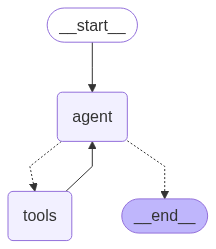

In [38]:
from IPython.display import Image, display
display(Image(app.get_graph().draw_mermaid_png()))

In [51]:
SYSTEM_PROMPT = "You are a helpful assistant tasked with using search and performing airthmetic operations. " \
    "You can use the following tools: \n" \
    "1. Addition Tool: Adds two numbers. Input format: 'a b'\n" \
    "2. Multiplication Tool: Multiplies two numbers. Input format: 'a b'\n" \
    "3. Division Tool: Divides two numbers. Input format: 'a b'\n" \
    "4. Search Tool: Searches the web for information. Input format: 'query'\n" \
    "You will receive a question and you should decide which tool to use based on the question. " \
    "You can use multiple tools if needed. " \
    "You will return the final answer after using the tools."

In [54]:
def function_1(state:MessagesState):
    user_question = state['messages']
    input_question = [SYSTEM_PROMPT] + user_question
    response = llm_with_tools.invoke(input_question)
    return {"messages": [response]
    }

In [55]:
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import MessagesState,StateGraph, END, START

In [56]:
builder=StateGraph(MessagesState)

In [57]:

builder.add_node("llm_decision_step",function_1)

In [58]:

tools

[StructuredTool(name='multiply', description='Multiplies two numbers.', args_schema=<class 'langchain_core.utils.pydantic.multiply'>, func=<function multiply at 0x12a00cd30>),
 StructuredTool(name='add', description='Adds two numbers.', args_schema=<class 'langchain_core.utils.pydantic.add'>, func=<function add at 0x12a00cb80>),
 StructuredTool(name='divide', description='Divides two numbers.', args_schema=<class 'langchain_core.utils.pydantic.divide'>, func=<function divide at 0x12a05fe20>),
 DuckDuckGoSearchRun(api_wrapper=DuckDuckGoSearchAPIWrapper(region='us-en', safesearch='moderate', time='y', max_results=3, backend='auto', source='text'))]

In [59]:
from langgraph.prebuilt import ToolNode
builder.add_node("tools",ToolNode(tools))

In [60]:
builder.add_edge(START,"llm_decision_step")

In [61]:
from langgraph.prebuilt import tools_condition
builder.add_conditional_edges(
    "llm_decision_step",
    tools_condition,
)

In [62]:

builder.add_edge("tools","llm_decision_step")

In [68]:

react_graph=builder.compile()

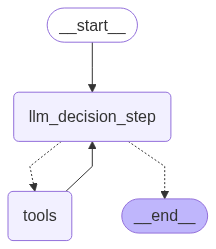

In [69]:
from IPython.display import Image, display
display(Image(react_graph.get_graph().draw_mermaid_png()))

In [70]:
message = [HumanMessage(content="What is 2* age of narendra modi?")]
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content='What is 2* age of narendra modi?', additional_kwargs={}, response_metadata={}, id='733a651d-bfe2-49b9-90d2-0b465536f82c'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'd356vrwyd', 'function': {'arguments': '{"query":"Narendra Modi age"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 192, 'prompt_tokens': 415, 'total_tokens': 607, 'completion_time': 0.698181818, 'prompt_time': 0.031250929, 'queue_time': 0.22015379100000004, 'total_time': 0.729432747}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--d17f6324-2ce4-487d-abfa-555f884015ee-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Narendra Modi age'}, 'id': 'd356vrwyd', 'type': 'tool_call'}], usage_metadata={'input_tokens': 415, 'output_tokens': 192, 'total_tokens': 607}),
  ToolMessage(content='Narendra 

In [71]:
message = [HumanMessage(content="What is the net worth of Elon Musk divided by 2?")]
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content='What is the net worth of Elon Musk divided by 2?', additional_kwargs={}, response_metadata={}, id='5bc501dd-5e22-4be9-9d1f-3ad231cdcf44'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'ww7aew6xc', 'function': {'arguments': '{"query":"Elon Musk net worth 2023"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 178, 'prompt_tokens': 416, 'total_tokens': 594, 'completion_time': 0.647272727, 'prompt_time': 0.026732656, 'queue_time': 0.21696625, 'total_time': 0.674005383}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--98b8ca16-ac35-4f5a-a37d-651dc4962e97-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'Elon Musk net worth 2023'}, 'id': 'ww7aew6xc', 'type': 'tool_call'}], usage_metadata={'input_tokens': 416, 'output_tokens': 178, 'total_tokens': 594}),
  ToolMessa

In [72]:
message = [HumanMessage(content="What is the speed of light in km/s * 2.5?")]
react_graph.invoke({"messages": message})

{'messages': [HumanMessage(content='What is the speed of light in km/s * 2.5?', additional_kwargs={}, response_metadata={}, id='6dcc7323-89d0-4535-9d08-4aecc825c388'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'r4esy372p', 'function': {'arguments': '{"query":"speed of light in km/s"}', 'name': 'duckduckgo_search'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 324, 'prompt_tokens': 418, 'total_tokens': 742, 'completion_time': 1.178181818, 'prompt_time': 0.027001451, 'queue_time': 0.219984365, 'total_time': 1.205183269}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--0b6d1291-4502-4009-a85d-78eee78fb108-0', tool_calls=[{'name': 'duckduckgo_search', 'args': {'query': 'speed of light in km/s'}, 'id': 'r4esy372p', 'type': 'tool_call'}], usage_metadata={'input_tokens': 418, 'output_tokens': 324, 'total_tokens': 742}),
  ToolMessage(content

In [73]:
response = react_graph.invoke({"messages": [HumanMessage(content="What is the latest news about iPhone 17?")]})
print(response['messages'][-1].content)

The latest news about the iPhone 17 includes details about its design and features. The iPhone 17 Pro is expected to have a redesigned camera system with a three-lens arrangement on a new panel that stretches across the phone's width. Additionally, it is rumored to feature a partially glass body. These updates suggest significant improvements in both aesthetics and functionality.


In [74]:
for m in response['messages']:
    m.pretty_print()

================================ Human Message =================================

What is the latest news about iPhone 17?
================================== Ai Message ==================================
Tool Calls:
  duckduckgo_search (1n8v26fra)
 Call ID: 1n8v26fra
  Args:
    query: latest news iPhone 17
================================= Tool Message =================================
Name: duckduckgo_search

iPhone 17: Price. We haven't yet heard if the iPhone 17 line will cost the same as the iPhone 16 line. Most rumors suggest the "Plus" model will be replaced by the new super-slim "Air ... The latest rumors suggest the iPhone 17 Pro's three-lens camera arrangement will be maintained, but will sit on a new panel that stretches across the phone's width. New iPhone 17 Pro dummy leak highlights redesigned camera and part glass body. ... Latest in News. Nintendo delays live-action 'Zelda' movie — here's when it'll now hit theaters.
================================== Ai Message =======

In [95]:
import yfinance as yf
from langchain.tools import tool
import time

@tool
def get_stock_price(ticker: str) -> float:
    """Fetches the current stock price for a given ticker symbol."""
    max_retries = 3
    for attempt in range(max_retries):
        try:
            stock = yf.Ticker(ticker)
            # Add delay between requests
            time.sleep(2)
            history = stock.history(period="1d")
            if history.empty:
                raise ValueError(f"No data found for ticker {ticker}")
            return float(history['Close'].iloc[-1])
        except Exception as e:
            if attempt < max_retries - 1:
                print(f"Attempt {attempt + 1} failed, retrying in 5 seconds...")
                time.sleep(5)
            else:
                raise ValueError(f"Error fetching stock price for {ticker}: {str(e)}")

In [96]:
# Update your tools list to include the stock price tool
tools = [
    multiply,
    add,
    divide,
    search,  # or wikipedia if search is not working
    get_stock_price
]

# Update llm_with_tools to include the new tool
llm_with_tools = llm.bind_tools(tools)

# Update your system prompt to include stock price functionality
SYSTEM_PROMPT = "You are a helpful assistant tasked with using search, performing arithmetic operations, and fetching stock prices. " \
    "You can use the following tools: \n" \
    "1. Addition Tool: Adds two numbers\n" \
    "2. Multiplication Tool: Multiplies two numbers\n" \
    "3. Division Tool: Divides two numbers\n" \
    "4. Search Tool: Searches the web for information\n" \
    "5. Stock Price Tool: Fetches current stock price for a ticker symbol\n" \
    "You will receive a question and decide which tool(s) to use. " \
    "You can use multiple tools if needed and return the final answer."

In [97]:
# Test the agent with stock-related queries
message = [HumanMessage(content="What is the current price of Apple stock multiplied by 2?")]
response = react_graph.invoke({"messages": message})
print(response['messages'][-1].content)



I apologize for the confusion earlier. Let's break down your request step by step.

1. **Current Price of Apple Stock**: I'll use the DuckDuckGo Search tool to find the current price of Apple stock (AAPL).

2. **Multiply by 2**: Once I have the current price, I'll use the Multiply tool to double that price.

Please allow me to execute these steps for you.


In [98]:
response

{'messages': [HumanMessage(content='What is the current price of Apple stock multiplied by 2?', additional_kwargs={}, response_metadata={}, id='9dd7045d-f539-4cd4-a941-140cb2e5254b'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': '62hqmf5m4', 'function': {'arguments': '{"ticker":"AAPL"}', 'name': 'get_stock_price'}, 'type': 'function'}]}, response_metadata={'token_usage': {'completion_tokens': 279, 'prompt_tokens': 439, 'total_tokens': 718, 'completion_time': 1.014545455, 'prompt_time': 0.028065301, 'queue_time': 0.217761015, 'total_time': 1.042610756}, 'model_name': 'deepseek-r1-distill-llama-70b', 'system_fingerprint': 'fp_1bbe7845ec', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run--0f980707-2731-4f16-b561-268f4f982db8-0', tool_calls=[{'name': 'get_stock_price', 'args': {'ticker': 'AAPL'}, 'id': '62hqmf5m4', 'type': 'tool_call'}], usage_metadata={'input_tokens': 439, 'output_tokens': 279, 'total_tokens': 718}),
  ToolMessage(content='Error: get_stock_pri

In [99]:

# Test the agent with a stock price query
message = [HumanMessage(content="What is the current stock price of Tesla?")]
response = react_graph.invoke({"messages": message})
print(response['messages'][-1].content)

The current stock price of Tesla (TSLA) can be found by checking financial news websites or stock market tracking platforms. You can use the duckduckgo_search tool with a query like "Tesla stock price" to find the latest information.
